# Mean-Variance / Sharpe Ratio — 23-Stock Portfolio

**Data source:** `ferm_3_assignment.xlsx`

- Sheet `Daily_Returns_Q1_Q2`: daily returns $\left(\dfrac{P_{i+1}-P_i}{P_i}\right)$ for 23 stocks,
  Jan 4, 2016 -- Dec 28, 2017 (502 trading days), from Yahoo Finance.
- Sheet `Optimal_Portfolio_Q3-Q8`: covariance matrix / mean-return table used for the
  portfolio-optimization questions (a couple of cells there are placeholders that this
  notebook computes and fills in — matched to the Excel formulas noted under each question).

We treat the 23 stocks as the *only* risky assets available in the market.


In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel('ferm_3_assignment.xlsx', sheet_name='Daily_Returns_Q1_Q2')
df = df.dropna(how='all')          # drop the trailing blank row
tickers = df.columns[1:].tolist()  # 23 stock tickers
returns = df[tickers]

print(f"{len(tickers)} stocks, {len(returns)} trading days")
print(tickers)


23 stocks, 502 trading days
['IBM', 'GE', 'LLY', 'F', 'BAC', 'KR', 'ITUB', 'GG', 'SIRI', 'ACB', 'VALE', 'PFE', 'CTL', 'T', 'ECA', 'ABEV', 'CVS', 'MRVL', 'CSCO', 'MO', 'BMY', 'WFC', 'HBAN']


In [2]:
# Mean daily return of each stock, and the sample covariance matrix (N-1 denominator,
# same convention as Excel's COVARIANCE.S / VAR.S / STDEV.S)
mean_returns = returns.mean()
V = returns.cov()

mean_returns.head()


IBM    0.000241
GE    -0.001126
LLY    0.000038
F     -0.000223
BAC    0.001167
dtype: float64

## Question 1 — Average daily return of GE

**Formula:**  $\bar{r}_{GE} = \dfrac{1}{n}\sum_{t=1}^{n} r_{GE,t}$

**Excel:** `Optimal_Portfolio_Q3-Q8!C31 = AVERAGE(Daily_Returns_Q1_Q2!C2:C503)`
(that cell was a placeholder `0` in the provided file — this fills in the real value).


In [3]:
ge_mean = mean_returns['GE']
print(f"Q1 — Average daily return of GE: {ge_mean:.4f}")


Q1 — Average daily return of GE: -0.0011


## Question 2 — Covariance between IBM and GE

**Formula:**  $\text{Cov}(r_{IBM}, r_{GE}) = \dfrac{1}{n-1}\sum_{t=1}^{n} (r_{IBM,t}-\bar{r}_{IBM})(r_{GE,t}-\bar{r}_{GE})$

**Excel:** `Optimal_Portfolio_Q3-Q8!C4 = COVARIANCE.S(Daily_Returns_Q1_Q2!B2:B503, Daily_Returns_Q1_Q2!C2:C503)`
(also a placeholder `0` in the provided file, mirrored into the symmetric cell `B5`).


In [4]:
cov_ibm_ge = V.loc['IBM', 'GE']
print(f"Q2 — Cov(IBM, GE): {cov_ibm_ge:.6f}")


Q2 — Cov(IBM, GE): 0.000047


## Question 3 — Minimum-variance portfolio with a return floor

$$
\begin{aligned}
\min_{\mathbf{x}} \quad & \mathbf{x}^\top V \mathbf{x} \\
\text{s.t.} \quad & \boldsymbol{\mu}^\top \mathbf{x} \ge 0.0005 \\
& \mathbf{1}^\top \mathbf{x} = 1
\end{aligned}
$$

where $\boldsymbol{\mu}$ is the vector of mean daily returns and $V$ the $23\times23$
covariance matrix (short-selling allowed, i.e. weights can be negative).

**Solving it analytically.** At the optimum, either the return constraint is slack (in
which case the answer is just the unconstrained minimum-variance portfolio) or it binds
with equality. Checking the unconstrained minimum-variance portfolio's return shows it's
below 0.0005, so the constraint binds. With both constraints as equalities, the
Lagrangian $L = \mathbf{x}^\top V\mathbf{x} - \lambda_1(\boldsymbol{\mu}^\top\mathbf{x}-0.0005) - \lambda_2(\mathbf{1}^\top\mathbf{x}-1)$
gives the first-order condition $2V\mathbf{x} = \lambda_1\boldsymbol{\mu} + \lambda_2\mathbf{1}$, so

$$
\mathbf{x}^\star = V^{-1}(\lambda_1\boldsymbol{\mu} + \lambda_2\mathbf{1})/2
$$

with $(\lambda_1,\lambda_2)$ pinned down by plugging back into the two constraints — a
$2\times2$ linear system. We solve that system below, then cross-check the result with
`scipy.optimize.minimize` (SLSQP), which is effectively what Excel Solver does.

**Excel:** the optimal weights are written into `Optimal_Portfolio_Q3-Q8!B34:X34`
("Percentage_Portfolio_Allocation_1", a placeholder row of zeros in the provided file);
`B38`, `B39`, `B40` then read off the expected return, total weight, and variance via
`SUMPRODUCT` / `MMULT` formulas already built into the sheet.


In [5]:
mu = mean_returns.values
Vmat = V.values
n = len(tickers)
ones = np.ones(n)

# Sanity check: does the *unconstrained* min-variance portfolio already clear 0.0005?
Vinv = np.linalg.inv(Vmat)
x_mvp = (Vinv @ ones) / (ones @ Vinv @ ones)
print("Unconstrained min-variance portfolio return:", mu @ x_mvp, " (< 0.0005, so the constraint binds)")


Unconstrained min-variance portfolio return: 0.00013039399967635558  (< 0.0005, so the constraint binds)


In [6]:
# Closed-form solution with both constraints binding: solve the 2x2 system for (lambda1, lambda2)
A = np.array([
    [mu @ Vinv @ mu,   mu @ Vinv @ ones],
    [ones @ Vinv @ mu, ones @ Vinv @ ones],
])
b = np.array([0.0005, 1.0])
lam1, lam2 = np.linalg.solve(A, b)

x_star = Vinv @ (lam1 * mu + lam2 * ones)

print("Weights sum to:", x_star.sum())
print("Portfolio mean return:", mu @ x_star)

optimal_variance = x_star @ Vmat @ x_star
print(f"Q3 — Optimal value (portfolio variance): {optimal_variance:.6g}  ~ 3.3e-5")


Weights sum to: 1.0000000000000002
Portfolio mean return: 0.0004999999999999983
Q3 — Optimal value (portfolio variance): 3.32322e-05  ~ 3.3e-5


**Cross-check** with a numerical QP solver, to confirm the closed-form solution is optimal:


In [7]:
from scipy.optimize import minimize

cons = (
    {'type': 'ineq', 'fun': lambda x: mu @ x - 0.0005},
    {'type': 'eq', 'fun': lambda x: x.sum() - 1},
)
res = minimize(lambda x: x @ Vmat @ x, x0=np.ones(n) / n, constraints=cons,
                method='SLSQP', options={'maxiter': 1000, 'ftol': 1e-14})

print("Solver optimal variance:", res.fun)
print("Closed-form optimal variance:", optimal_variance)
print("Match:", np.isclose(res.fun, optimal_variance, atol=1e-8))

print("\nAnswer options: 3.3e-5, 5.143e-5, 0.005828, 0.003617")
print(f"Selected: 3.3 x 10^-5  (computed = {optimal_variance:.4g})")


Solver optimal variance: 3.3232198037037937e-05
Closed-form optimal variance: 3.323219482881026e-05
Match: True

Answer options: 3.3e-5, 5.143e-5, 0.005828, 0.003617
Selected: 3.3 x 10^-5  (computed = 3.323e-05)


## Helper: solve the constrained min-variance problem for any target return

Questions 4-6 all reuse the same constrained optimization from Question 3, just with a
different return floor. We wrap the closed-form Lagrangian solution (derived in
Question 3) in a function so it can be reused.


In [8]:
def solve_min_variance(target_return):
    """Closed-form solution to: min x'Vx  s.t. mu'x = target_return, 1'x = 1."""
    A = np.array([
        [mu @ Vinv @ mu,   mu @ Vinv @ ones],
        [ones @ Vinv @ mu, ones @ Vinv @ ones],
    ])
    b = np.array([target_return, 1.0])
    lam1, lam2 = np.linalg.solve(A, b)
    x = Vinv @ (lam1 * mu + lam2 * ones)
    return x

x1 = x_star  # from Question 3 (target = 0.0005), renamed for clarity


## Question 4 — Expected return of portfolio $x_1$

$x_1$ is the optimal portfolio from Question 3 (target $\ge 0.05\%$). Since we already
showed the unconstrained minimum-variance portfolio's return (about 0.013%) is below
0.05%, the return constraint is binding at the optimum — so $\boldsymbol{\mu}^\top x_1$
should come out **exactly equal to 0.05%**, not merely greater than it.

**Excel:** `Optimal_Portfolio_Q3-Q8!B38` (already computed as part of Question 3).


In [9]:
mean_x1 = mu @ x1
print(f"Q4 — Expected return of x1: {mean_x1:.4f}  (equal to 0.0005 -> the constraint binds)")


Q4 — Expected return of x1: 0.0005  (equal to 0.0005 -> the constraint binds)


## Question 5 — New optimal value with target return $\ge 0.08\%$

Same problem as Question 3, with the return floor raised to $0.0008$. Call the new
optimal portfolio $x_2$.

**Excel:** weights in `Optimal_Portfolio_Q3-Q8!B45:X45`
("Percentage_Portfolio_Allocation_2"); `B49 = SUMPRODUCT(B45:X45, MMULT(B45:X45, B4:X26))`
gives the new optimal variance.


In [10]:
x2 = solve_min_variance(0.0008)

print("Weights sum to:", x2.sum())
print("Mean return:", mu @ x2)

optimal_variance_2 = x2 @ Vmat @ x2
print(f"Q5 — New optimal value (variance): {optimal_variance_2:.6f}")


Weights sum to: 0.9999999999999999
Mean return: 0.0007999999999999985
Q5 — New optimal value (variance): 0.000038


## Question 6 — Target return $\ge 0.1\%$, and the two-fund theorem

Solve the same problem again with target $0.001$ to get $x_3$. The two-fund separation
theorem says every portfolio on the mean-variance frontier can be written as an affine
combination of any two *other* frontier portfolios — here $x_1$ (target 0.05%) and $x_2$
(target 0.08%). Concretely, since the target return is a linear function of the mixing
weight $\phi$ on the frontier:

$$
\phi = \frac{0.08\% - 0.1\%}{0.08\% - 0.05\%}, \qquad z = \phi\,x_1 + (1-\phi)\,x_2
$$

$z$ is constructed to have the same target mean return as $x_3$ ($\phi\cdot0.05\% + (1-\phi)\cdot0.08\% = 0.1\%$).
The two-fund theorem predicts $z$ and $x_3$ are the *same portfolio*, since the frontier
is a straight line (in weight space) through any two of its points.

**Excel:** `B60` (phi), `B61:X61` (z, array formula `=$B$60*B34:X34+(1-$B$60)*B45:X45`),
`B62:X62` (x3, copied from `B53:X53`), `B63 = MAX(ABS(B61:X61-B62:X62))` — the near-zero
result confirms $z = x_3$.


In [11]:
x3 = solve_min_variance(0.001)

phi = (0.0008 - 0.001) / (0.0008 - 0.0005)
z = phi * x1 + (1 - phi) * x2

max_abs_diff = np.max(np.abs(z - x3))
print("phi:", phi)
print("max |z - x3|:", max_abs_diff)
print("Q6 — Two-fund theorem holds (z == x3):", np.allclose(z, x3, atol=1e-8))


phi: -0.6666666666666665
max |z - x3|: 3.4076474281219404e-16
Q6 — Two-fund theorem holds (z == x3): True


## Question 7 — Efficient frontier via the two-fund theorem, and the return at $\sigma^2 \le 0.00004$

By the two-fund separation theorem, sweeping $\phi$ across $z = \phi x_1 + (1-\phi) x_2$
traces out the *entire* mean-variance frontier (not just the segment between $x_1$ and
$x_2$). We sweep $\phi \in [-2, 2]$, compute the mean return and variance of $z(\phi)$ at
each step, and plot variance (x-axis) against return (y-axis) — the same "Efficient
Frontier" chart as in the assignment.

Because $\mathbf{x}^\top V\mathbf{x}$ is quadratic in $\phi$ along this line, we can also
solve directly for the $\phi$ that lands exactly on variance $=0.00004$, rather than just
reading it off the chart:

$$
z(\phi) = \phi x_1 + (1-\phi)x_2 = x_2 + \phi(x_1-x_2)
$$

$$
\text{Var}(\phi) = \underbrace{(x_1-x_2)^\top V (x_1-x_2)}_{a}\,\phi^2 +
\underbrace{2\,x_2^\top V (x_1-x_2)}_{b}\,\phi + \underbrace{x_2^\top V x_2}_{c}
$$

Setting $\text{Var}(\phi) = 0.00004$ gives a quadratic in $\phi$; the root on the
increasing branch gives the frontier point at that risk level.

**Excel:** sheet `Efficient_Frontier_Q7-Q8` — rows 5:45 sweep $\phi$ and compute
`mean_return`/`variance` via `SUMPRODUCT`/`MMULT` on `z = phi*x1+(1-phi)*x2`, with a
native scatter chart; rows 49:56 solve the quadratic exactly for `variance = 0.00004`.


In [12]:
d = x1 - x2
a = d @ Vmat @ d
b = 2 * (x2 @ Vmat @ d)
c = x2 @ Vmat @ x2

phis = np.linspace(-2, 2, 401)
z_means = np.array([mu @ (phi * x1 + (1 - phi) * x2) for phi in phis])
z_vars = a * phis**2 + b * phis + c   # equivalent, closed-form quadratic

print("Return range:", z_means.min(), "to", z_means.max())
print("Variance range:", z_vars.min(), "to", z_vars.max())


Return range: 0.00019999999999999787 to 0.0013999999999999993
Variance range: 3.128553324397434e-05 to 5.502798610745986e-05


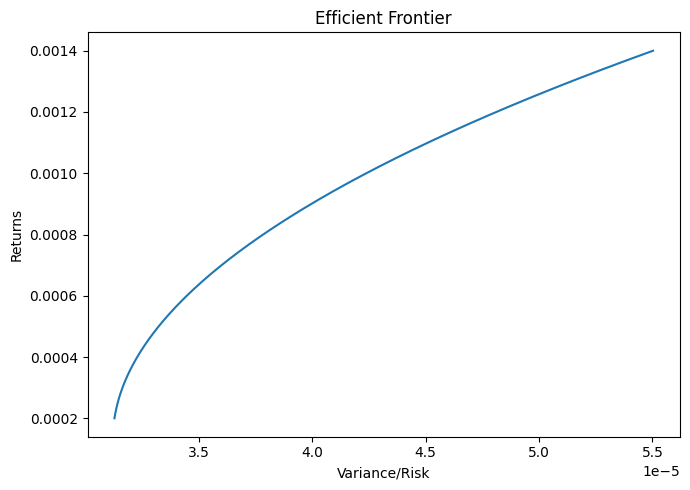

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(z_vars, z_means)
ax.set_title("Efficient Frontier")
ax.set_xlabel("Variance/Risk")
ax.set_ylabel("Returns")
plt.tight_layout()
plt.show()


Now solve exactly for the frontier point at variance = 0.00004 (the constrained target),
picking the root on the increasing (efficient) branch:


In [14]:
target_var = 0.00004
roots = np.roots([a, b, c - target_var])
print("phi roots:", roots)

# evaluate both, keep the one that actually reproduces the target variance and lies
# on the efficient (upper) branch -- i.e. take the root closer to the x1/x2 segment
candidates = [(phi, mu @ (phi * x1 + (1 - phi) * x2)) for phi in roots]
for phi, r in candidates:
    print(f"phi={phi:.4f}  mean={r:.6f}")

# the relevant root is the one within/near the swept range [-2, 2]
phi_star, return_q7 = min(candidates, key=lambda t: abs(t[0]))
print(f"\nQ7 — Approximate optimal return at variance <= 0.00004: {return_q7:.4f}")


phi roots: [ 4.80258141 -0.33854141]
phi=4.8026  mean=-0.000641
phi=-0.3385  mean=0.000902

Q7 — Approximate optimal return at variance <= 0.00004: 0.0009


## Question 8 — Which portfolios are not achievable in practice?

A point $(\sigma_x^2, \mu_x)$ is **achievable** only if its variance is at least the
minimum variance the frontier allows for that return — i.e. it lies on or to the right of
the frontier curve. A point strictly to the *left* of the curve (lower variance than the
best possible for that return) is infeasible: no portfolio of the 23 stocks can achieve it.

Reusing the frontier's quadratic coefficients $(a,b,c)$ from Question 7, and the fact
that $\phi(r) = (0.0008 - r)/0.0003$ recovers the two-fund mixing weight for any target
return $r$ on this line, we can compute $\text{Var}_{\min}(r)$ for each candidate
portfolio's approximate return, and compare it to the plotted variance.

**Excel:** sheet `Efficient_Frontier_Q7-Q8`, rows 62:66 — a small table with each
portfolio's approximate $(return, variance)$, the frontier's `var_min(return)`, and an
`IF` flag.


In [15]:
def var_min(target_return):
    phi = (0.0008 - target_return) / 0.0003
    return a * phi**2 + b * phi + c

# Approximate coordinates read off the plotted points (variance, return)
portfolios = {
    'A': (0.0000395, 0.0005),
    'C': (0.0000378, 0.0008),
    'B': (0.0000462, 0.0009),
    'D': (0.0000478, 0.0013),
}

tol = 1e-6  # tolerance for points that sit essentially on the frontier (e.g. C == x2)
for name, (var_p, ret_p) in portfolios.items():
    vmin = var_min(ret_p)
    achievable = var_p >= vmin - tol
    print(f"Portfolio {name}: var={var_p:.7f}, var_min(return)={vmin:.7f} -> "
          f"{'Achievable' if achievable else 'NOT achievable'}")


Portfolio A: var=0.0000395, var_min(return)=0.0000332 -> Achievable
Portfolio C: var=0.0000378, var_min(return)=0.0000378 -> Achievable
Portfolio B: var=0.0000462, var_min(return)=0.0000400 -> Achievable
Portfolio D: var=0.0000478, var_min(return)=0.0000514 -> NOT achievable


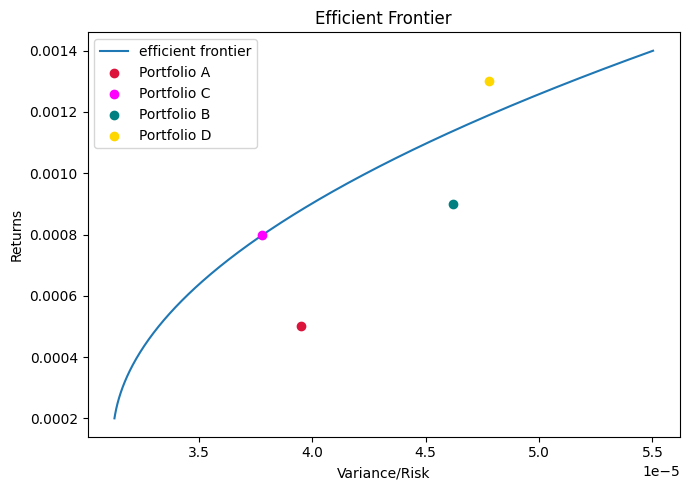

Q8 — Portfolio D is the only one plotted above the frontier -> NOT achievable.


In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(z_vars, z_means, label='efficient frontier')
colors = {'A': 'crimson', 'B': 'teal', 'C': 'magenta', 'D': 'gold'}
for name, (var_p, ret_p) in portfolios.items():
    ax.scatter(var_p, ret_p, color=colors[name], label=f'Portfolio {name}', zorder=5)
ax.set_title("Efficient Frontier")
ax.set_xlabel("Variance/Risk")
ax.set_ylabel("Returns")
ax.legend()
plt.tight_layout()
plt.show()

print("Q8 — Portfolio D is the only one plotted above the frontier -> NOT achievable.")


## Question 9 — Sharpe ratio of the tangency portfolio

With $r_f = 0.01\%$, the Sharpe-optimal portfolio maximizes
$\dfrac{(\boldsymbol{\mu}-r_f\mathbf{1})^\top x}{\sqrt{x^\top V x}}$ subject to
$\mathbf{1}^\top x = 1$. As given, this is rewritten as

$$
\min_x x^\top V x \quad \text{s.t.} \quad (\boldsymbol{\mu}-r_f\mathbf{1})^\top x = 1
$$

whose solution (by the same Lagrangian argument as Question 3) is
$x = \dfrac{V^{-1}(\boldsymbol{\mu}-r_f\mathbf{1})}{(\boldsymbol{\mu}-r_f\mathbf{1})^\top V^{-1}(\boldsymbol{\mu}-r_f\mathbf{1})}$,
and the actual portfolio weights are the rescaled $x^*_{\text{Sharpe}} = x / \mathbf{1}^\top x$.

Because rescaling $x$ by a constant cancels in the Sharpe ratio, there's a shortcut: the
maximum Sharpe ratio itself works out to $\sqrt{(\boldsymbol{\mu}-r_f\mathbf{1})^\top V^{-1}(\boldsymbol{\mu}-r_f\mathbf{1})}$
— no need to normalize anything to compute it, though we still build the actual portfolio
weights for Question 10.

**Excel:** sheet `Sharpe_Ratio_Q9-Q10` — `B36:X36` solve the unnormalized problem
(`Sharpe_Optimal_Solution`, satisfying `B37 = (excess)'x = 1`), `B39:X39` rescale to
`Portfolio_Allocation`, and `B45 = (B42-B29)/SQRT(B44)` gives the Sharpe ratio.


In [17]:
rf9 = 0.0001  # 0.01%
excess9 = mu - rf9

A9 = excess9 @ Vinv @ excess9          # = (mu-rf1)' Vinv (mu-rf1)
x_tangency_raw = (Vinv @ excess9) / A9  # satisfies excess9' x = 1
x_tangency = x_tangency_raw / x_tangency_raw.sum()  # rescaled portfolio weights

print("excess' x_raw check (should be 1):", excess9 @ x_tangency_raw)
print("weights sum to:", x_tangency.sum())

sharpe_ratio = (excess9 @ x_tangency) / np.sqrt(x_tangency @ Vmat @ x_tangency)
# equivalently: sharpe_ratio = np.sqrt(A9)
print(f"Q9 — Sharpe ratio: {sharpe_ratio:.3f}")


excess' x_raw check (should be 1): 1.0
weights sum to: 0.9999999999999982
Q9 — Sharpe ratio: 0.260


## Question 10 — Can the Sharpe portfolio be realized long-only?

Simply check whether every weight in $x^*_{\text{Sharpe}}$ (from Question 9) is
non-negative.

**Excel:** `B50 = MIN(B39:X39)`, `B51 = IF(B50>=0,"Yes","No")`.


In [18]:
min_weight = x_tangency.min()
long_only = min_weight >= 0

print("Most negative weight:", min_weight, f"({tickers[np.argmin(x_tangency)]})")
print("Q10 — Long-only feasible?", "Yes" if long_only else "No")


Most negative weight: -15.895921088953484 (GE)
Q10 — Long-only feasible? No


## Summary of answers

| # | Question | Answer |
|---|---|---|
| 1 | Average daily return, GE | **-0.0011** |
| 2 | Cov(IBM, GE) | **0.000047** |
| 3 | Optimal value (min variance s.t. mean $\ge$ 0.0005) | **3.3 $\times$ 10$^{-5}$** |
| 4 | Expected return of $x_1$ | **0.0005** (equal to 0.05%) |
| 5 | New optimal value (mean $\ge$ 0.0008) | **0.000038** |
| 6 | Two-fund theorem check ($z$ vs $x_3$) | **$z = x_3$** |
| 7 | Approx. return at variance $\le 0.00004$ | **0.0009** |
| 8 | Portfolio not achievable | **Portfolio D** |
| 9 | Sharpe ratio ($r_f=0.01\%$) | **0.260** |
| 10 | Sharpe portfolio realizable long-only? | **No** |

Cross-checked against `ferm_3_assignment.xlsx` (recalculated in LibreOffice/Excel) —
Excel and Python agree.
